# Cardiovascular Disease Predictive Modelling

The purpose of this project is to analyze Cardiovascular study dataset from Kaggle and to fit a logistic regression model that predicts the risk of whether patient have 10 year risk of coronary heart disease CHD or not.

### About the Dataset

Dataset is from an ongoing cardiovascular study on residents of the town of Framingham, Massachusetts.



### Data Description

**Demographic**:
- sex: male or female
- age: in years
- education: from 1 to 4.

**Behavioral**:
- is_smoking: yes or no
- cigs_per_day: average number of cigarettes smoked in a day

**Medical history**:
- bp_meds (blood pressure medication): 1 or 0 (yes or no)
- prevalent_stroke: 1 or 0 (yes or no)
- prevalent_hyp (hypertensive): 1 or 0 (yes or no)
- diabetes: 1 or 0 (yes or no)

**Current medical data**:
- tot_chol (total cholesterol)
- sys_bp (systolic blood pressure)
- dia_bp (diastolic blood pressure)
- bmi (body mass index)
- heart_rate
- glucose (glucose level)

**Dependent variable**:
- ten_year_chd (10 year risk of coronary heart disease): 1 or 0 (yes or no)

### Agenda

1. Data loading and cleaning
2. EDA
3. Modelling
4. Conclusions and recommendations

# 1. Data Loading and Cleaning

### 1.1. Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from google.colab import data_table
data_table.enable_dataframe_formatter()

In [ ]:
"""
Global parameters
"""
plt.rcParams.update({
    "axes.labelsize": 12,
    "axes.titlesize": 16,
    "axes.titleweight": "bold"
})

In [ ]:
df = pd.read_csv("train.csv")
df.sample(10)

,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
2638,2638,57,NaN,M,YES,NaN,0.0,0,0,0,223.0,107.5,72.5,24.74,62.0,103.0,0
734,734,52,3.0,F,NO,0.0,0.0,0,0,0,254.0,126.5,93.0,26.79,75.0,65.0,0
1316,1316,54,2.0,F,NO,0.0,0.0,0,0,0,193.0,118.0,84.0,24.90,70.0,82.0,0
3126,3126,45,3.0,F,YES,10.0,0.0,0,0,0,210.0,121.0,82.0,23.08,85.0,71.0,1
2741,2741,53,1.0,F,YES,5.0,0.0,0,0,0,247.0,139.0,88.0,23.71,60.0,53.0,1
1671,1671,57,1.0,F,NO,0.0,0.0,0,0,0,277.0,133.0,84.0,36.21,62.0,74.0,0
3130,3130,59,2.0,M,YES,11.0,0.0,0,0,0,176.0,134.5,87.0,31.76,80.0,93.0,0
2791,2791,36,4.0,M,YES,35.0,0.0,0,0,0,240.0,114.0,76.0,25.82,66.0,NaN,0
2547,2547,43,2.0,F,YES,20.0,0.0,0,0,0,291.0,106.0,65.0,23.83,68.0,82.0,0
2304,2304,55,1.0,F,YES,5.0,0.0,0,1,0,280.0,144.0,79.0,19.50,79.0,75.0,1


In [ ]:
rows, columns = df.shape
print("Columns:", columns)
print("Rows:", rows)

Columns: 17
Rows: 3390


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   object 
 4   is_smoking       3390 non-null   object 
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
dtypes: float64(9),

In [ ]:
df.describe().round(2)

,id,age,education,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,3390.00,3390.00,3303.00,3368.00,3346.00,3390.00,3390.00,3390.00,3352.00,3390.00,3390.00,3376.00,3389.00,3086.00,3390.00
mean,1694.50,49.54,1.97,9.07,0.03,0.01,0.32,0.03,237.07,132.60,82.88,25.79,75.98,82.09,0.15
std,978.75,8.59,1.02,11.88,0.17,0.08,0.46,0.16,45.25,22.29,12.02,4.12,11.97,24.24,0.36
min,0.00,32.00,1.00,0.00,0.00,0.00,0.00,0.00,107.00,83.50,48.00,15.96,45.00,40.00,0.00
25%,847.25,42.00,1.00,0.00,0.00,0.00,0.00,0.00,206.00,117.00,74.50,23.02,68.00,71.00,0.00
50%,1694.50,49.00,2.00,0.00,0.00,0.00,0.00,0.00,234.00,128.50,82.00,25.38,75.00,78.00,0.00
75%,2541.75,56.00,3.00,20.00,0.00,0.00,1.00,0.00,264.00,144.00,90.00,28.04,83.00,87.00,0.00
max,3389.00,70.00,4.00,70.00,1.00,1.00,1.00,1.00,696.00,295.00,142.50,56.80,143.00,394.00,1.00


### 1.2. Data Standartization

I'll need to:
- Rename the columns to snake_case.
- Remove redundant index column.
- Remove irrelevant education column, as it can't be used to predict heart disease.
- Check for duplicate data.
- Transform values from is_smoking and sex columns into binary values.

In [ ]:
df = df.drop(columns=["id", "education"])

In [ ]:
df = df.rename(columns={
    "cigsPerDay": "cigs_per_day",
    "BPMeds": "bp_meds",
    "prevalentStroke": "prevalent_stroke",
    "prevalentHyp": "prevalent_hyp",
    "totChol": "tot_chol",
    "sysBP": "sys_bp",
    "diaBP": "dia_bp",
    "BMI": "bmi",
    "heartRate": "heart_rate",
    "TenYearCHD": "ten_year_chd"
})

In [ ]:
df.duplicated().any()

np.False_

In [ ]:
sex_map = {"M": 1, "F": 0}
smoker_map = {"YES": 1, "NO": 0}

df["sex_binary"] = df["sex"].map(sex_map)
df["smoking_binary"] = df["is_smoking"].map(smoker_map)

In [ ]:
df.sample(10)

,age,sex,is_smoking,cigs_per_day,bp_meds,prevalent_stroke,prevalent_hyp,diabetes,tot_chol,sys_bp,dia_bp,bmi,heart_rate,glucose,ten_year_chd,sex_binary,smoking_binary
65,37,F,YES,10.0,0.0,0,0,0,156.0,120.0,87.0,21.80,66.0,89.0,0,0,1
2924,36,F,NO,0.0,0.0,0,0,0,195.0,116.0,76.0,22.16,88.0,77.0,0,0,0
1345,45,M,YES,18.0,0.0,0,0,0,176.0,124.0,84.0,20.27,77.0,75.0,0,1,1
1743,43,F,YES,15.0,0.0,0,0,0,205.0,128.5,96.0,22.34,100.0,NaN,0,0,1
1335,63,F,NO,0.0,0.0,0,1,0,223.0,178.0,88.5,27.18,85.0,91.0,0,0,0
2606,60,M,NO,0.0,0.0,0,1,0,276.0,144.0,78.0,26.98,60.0,88.0,0,1,0
3094,59,M,YES,30.0,0.0,0,1,0,239.0,168.0,100.0,27.87,65.0,96.0,1,1,1
2413,46,F,YES,20.0,0.0,0,0,0,250.0,112.5,60.0,22.72,82.0,74.0,0,0,1
643,49,F,NO,0.0,0.0,0,0,0,225.0,115.5,72.5,21.83,69.0,NaN,1,0,0
2072,63,F,NO,0.0,0.0,0,1,0,306.0,177.0,96.0,32.51,90.0,126.0,1,0,0


### 1.3. Missing data

I'll need to:
- Count missing data
- Address the way to deal with missing data in the modelling stage.

In [ ]:
missing_sum = df.isna().sum().reset_index()
missing_sum.columns = ["column_name", "missing_data_count"]
missing_pct = ((df.isna().mean())*100).round(2).reset_index()
missing_pct.columns = ["column_name", "missing_data_pct"]
missing_df = pd.merge(
    missing_sum,
    missing_pct,
    on="column_name"
)
missing_df

,column_name,missing_data_count,missing_data_pct
0,age,0,0.00
1,sex,0,0.00
2,is_smoking,0,0.00
3,cigs_per_day,22,0.65
4,bp_meds,44,1.30
5,prevalent_stroke,0,0.00
6,prevalent_hyp,0,0.00
7,diabetes,0,0.00
8,tot_chol,38,1.12
9,sys_bp,0,0.00


- 6/15 columns have missing values.
- Dependent variable column does not have missing values.
- I need to find out if data is missing completely at random.

<Axes: >

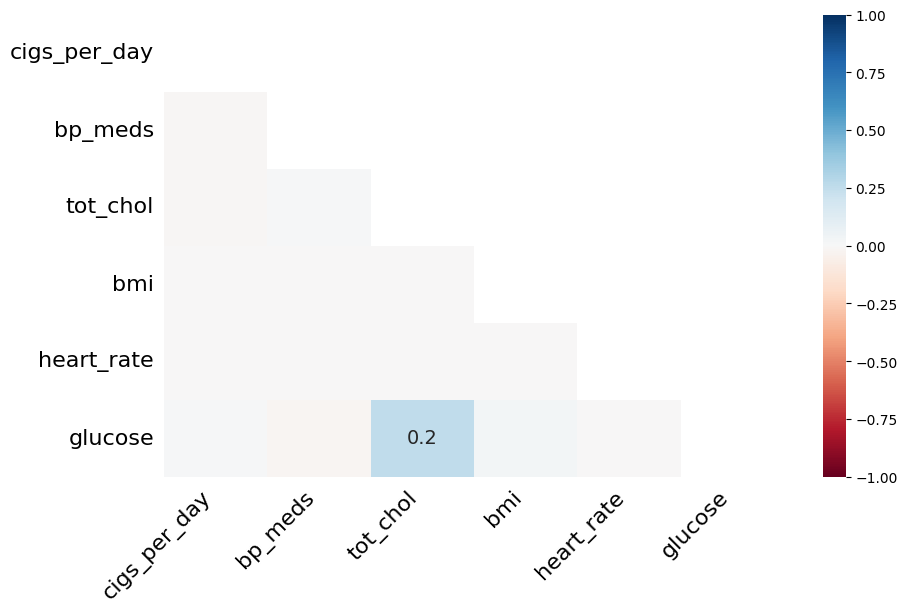

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))
msno.heatmap(df, ax=ax1)

It seems that values are missing completely at random, as correlation is either non-existant or very weak (as with tot_chol and glucose columns).

Missing values will be imputed at the modelling stage.

### 1.4. Checking for outliers

In [ ]:
numeric_cols = ["age", "cigs_per_day",
                "tot_chol", "sys_bp", "dia_bp",
                "bmi", "heart_rate", "glucose"]

for col in numeric_cols:
    fig = px.histogram(
        df,
        x=col,
        marginal="box",
        title=f"Distribution of {col}",
        color_discrete_sequence=["steelblue"],
        opacity=0.7
    )

    fig.update_layout(
        title={
            'font': {'size': 24},
            'x': 0.5,
            'xanchor': 'center'
        }
    )

    fig.show()


- "age" column has no outliers
- All the other columns are skewed to the right

Glucose column is very strongly skewed to the right. I'm going to log transform this column and try to normalize the distribution.

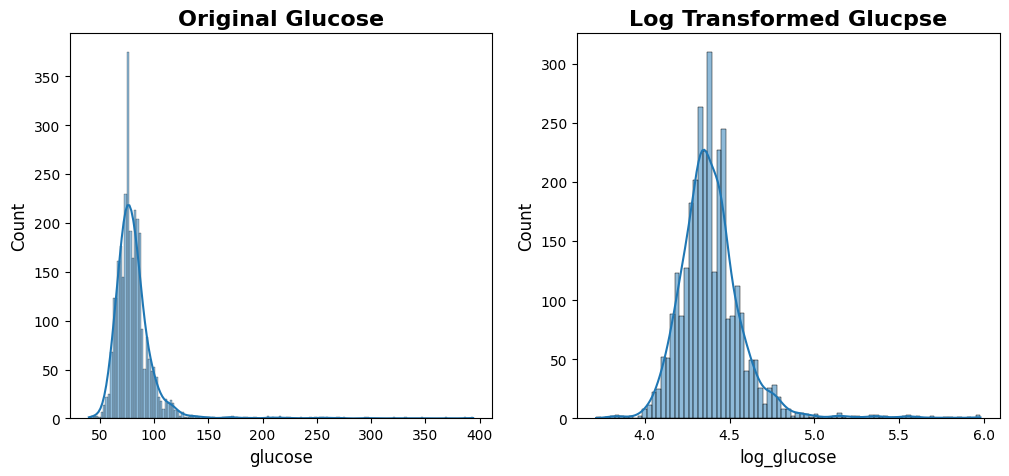

In [ ]:
df["log_glucose"] = np.log1p(df["glucose"])
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["glucose"], kde=True, ax=ax[0]).set_title("Original Glucose")
sns.histplot(df["log_glucose"], kde=True, ax=ax[1]).set_title("Log Transformed Glucpse")
plt.show()

In [ ]:
df.drop(columns=["glucose"], inplace=True)

We are going to clip the outliers at 1st and 99th percentile values so that some of the extreme results would still register as being very high or very low, without skewing the data that much.

In [ ]:
def windsorization (df, columns, limits=(0.01, 0.99)):
    for col in columns:
        lower_val = df[col].quantile(limits[0])
        upper_val = df[col].quantile(limits[1])
        df[col] = df[col].clip(lower=lower_val, upper=upper_val)
    return df

features = [
    "tot_chol", "sys_bp", "dia_bp",
    "bmi", "heart_rate", "log_glucose"
]
df = windsorization(df, features)

#2. Exploratory Data Analysis

My goal for this part:
- Find the strongest predictors for ten_year_chd.
- Find which columns are redundant and could be explained by others.
- Engineer some better features if necessary.

### 2.1. Correlation analysis

<Axes: >

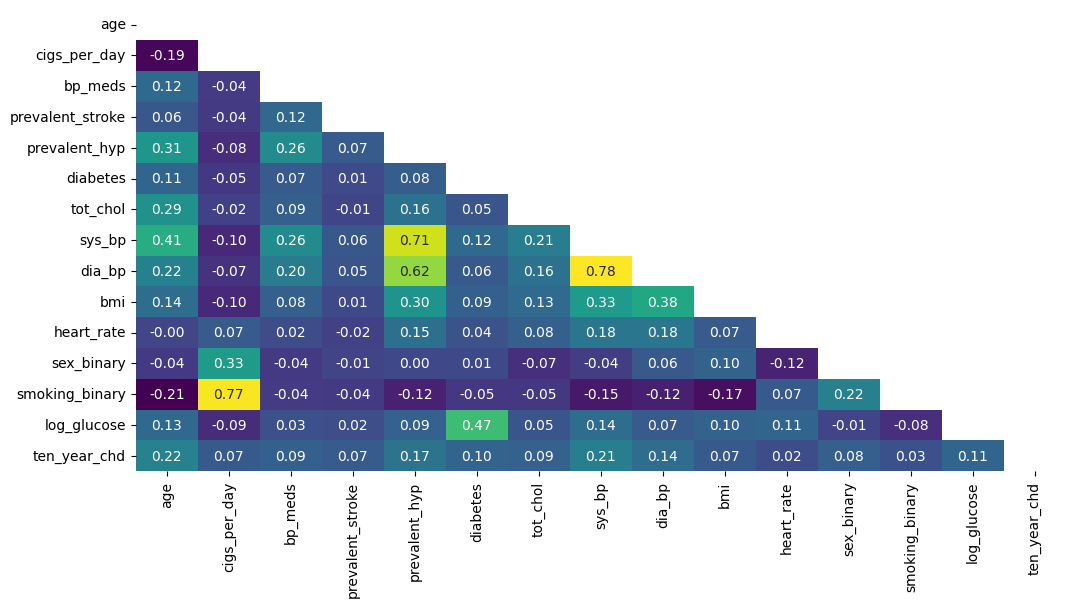

In [ ]:

"""
After adding new columns, I'm sorting the dataframe to
make correlation matrix easier to read.
"""
y = "ten_year_chd"
df = df[[c for c in df.columns if c != y] + [y]]

corr_matrix = df.corr(numeric_only=True)
corr_matrix_lower = corr_matrix.where(
    np.tril(np.ones(corr_matrix.shape), k=-1)
    .astype(bool)
)
corr_matrix_lower.index = corr_matrix.columns
corr_matrix_lower.columns = corr_matrix.columns

fig, axes = plt.subplots(figsize=(12, 6))
sns.heatmap(
    corr_matrix_lower,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    cbar=False
)

Strongest variables:
- age
- sys_bp

Variables I'm removing:
- dia_bp and prevalent_hyp: both strongly correlated with sys_bp, which is a stronger predictor.

Other changes I'm considering:
- binary variables bp_meds, prevalent_stoke and diabetes seem to be rather weak predictors, despite logic indicating otherwise. All of them have quite low representation in the dataset and it might be best to combine them into a single "comorbidities" variable.
- cigs_per_day and smoking_binary measures the same thing but I'm yet unsure which one should I drop.

### 2.2. Distribution of continuous variables

In [ ]:
numeric_cols = ["age", "cigs_per_day",
                "tot_chol", "sys_bp", "bmi",
                "heart_rate", "log_glucose"]
color_map = {0: "indianred", 1: "steelblue"}

for col in numeric_cols:
    fig = px.histogram(
        df,
        x=col,
        color="ten_year_chd",
        color_discrete_map=color_map,
        marginal="box",
        title=f"Distribution of {col}",
        barmode="overlay",
        opacity=0.7
    )

    fig.update_layout(
        title={
            "font": {"size": 24},
            "x": 0.5,
            "xanchor": "center"
        }
    )
    fig.show()

Variables I'm keeping:
- Age seems to be the best predictor, as there are visibly more patients at risk who are older, not just in percentages, but in raw count.
- sys_bp: strong predictor, visible difference in distribution.

Variables I'm removing:
- heart_rate - no difference in distribution.
- cigs_per_day have very unsual distribution which could affect the results. Plus, it is less reliably measured value than simple smoking_binary.

Variables I'm still considering:
- bmi and tot_chol - hardly any difference in distribution, but also no strong correlations with any other variable.
- log_glucose - little difference in distribution, other than the right tail. Risk of people with a very high glucose level could be better predicted by using diabetes variable.

### 2.3. Distribution of binary variables

In [ ]:
binary_cols = ["sex", "is_smoking", "prevalent_stroke",
               "diabetes", "bp_meds"]
color_map = {0: "indianred", 1: "steelblue"}

for col in binary_cols:
    n_counts = df[col].value_counts()
    n0 = n_counts.iloc[0]
    n1 = n_counts.iloc[1]
    ct = pd.crosstab(
        df[col],
        df["ten_year_chd"],
        normalize="index"
    ).round(3)*100
    ct = ct.reset_index().melt(
        id_vars=col,
        value_name="chd_pct"
    )

    fig = px.bar(
        ct,
        x=col,
        y="chd_pct",
        color="ten_year_chd",
        color_discrete_map=color_map,
        title=f"CHD risk by {col} (n0={n0}, n1={n1})",
        labels={
            "chd_pct": "Percentage (%)",
            "ten_year_chd": "CHD Risk Status"
        },
        barmode="stack",
        opacity=0.7
    )

    fig.update_layout(
        title={
            "font": {"size": 24},
            "x": 0.5,
            "xanchor": "center"
        }
    )

    fig.show()

Variables I'm keeping:
- Results are evenly distributed among the sexes and despite this, men are more affected by chd_risk than women on average. Sex is not the strongest predictor but it seems consistent and can't be explained by anything else.
- smoking_binary, because I've dropped cigs_per_day

Variables I'm reworking:
- prevalent_stroke, diabetes and bp_meds variable have especially uneven distribution among the categories but among those that do have these comorbidities, there are clear signs that these are important criteria for predicting chd risk.
- I'm combining them into one single "comorbidities" variable that requires a person to possess at least 1 of 3 possible health issues.

### 2.4. Feature engineering

In [ ]:
df["comorbidities"] = (
    (df['prevalent_stroke'] == 1) |
     (df['bp_meds'] == 1) |
    (df["diabetes"])
     ).astype(int)

n_counts = df["comorbidities"].value_counts()
n0 = n_counts.iloc[0]
n1 = n_counts.iloc[1]
ct = pd.crosstab(
    df["comorbidities"],
    df["ten_year_chd"],
    normalize="index"
).round(3)*100
ct = ct.reset_index().melt(
    id_vars="comorbidities",
    value_name="chd_pct"
)

color_map = {0: "indianred", 1: "steelblue"}
fig = px.bar(
    ct,
    x="comorbidities",
    y="chd_pct",
    color="ten_year_chd",
    color_discrete_map=color_map,
    title=f"CHD risk by {"comorbidities"} (n0={n0}, n1={n1})",
    labels={
        "chd_pct": "Percentage (%)",
        "ten_year_chd": "CHD Risk Status"
    },
    barmode="stack",
    opacity=0.7
)

fig.update_layout(
    title={
        "font": {"size": 24},
        "x": 0.5,
        "xanchor": "center"
    }
)

fig.show()

### 2.5. One Final Look at the Correlation Matrix

Predictors I've selected:
- age
- sex
- comorbidities
- sys_bp
- tot_chol
- smoking_binary
- bmi
- log_glucose

<Axes: >

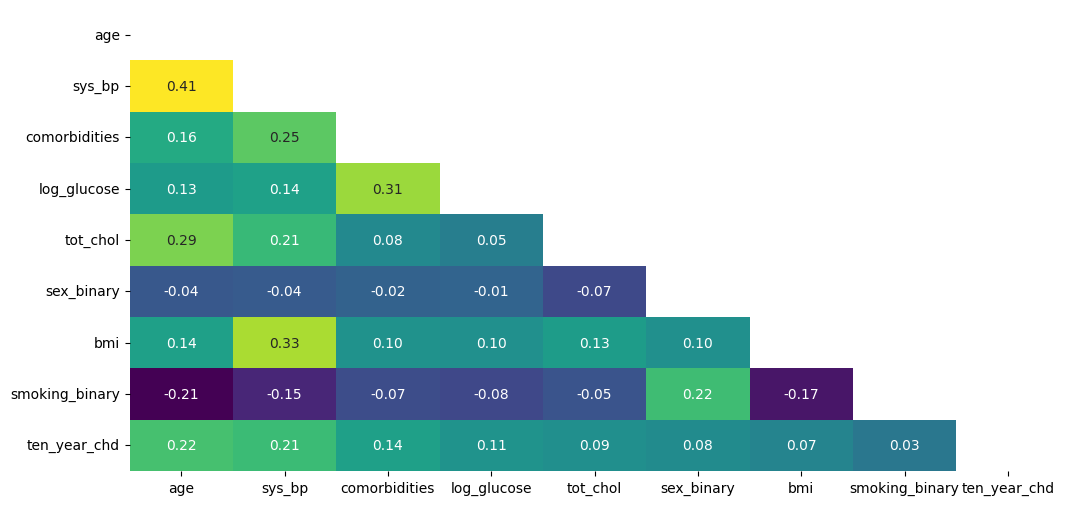

In [ ]:
features = [
    "age", "sys_bp", "comorbidities",
    "log_glucose", "tot_chol", "sex_binary",
    "bmi", "smoking_binary", "ten_year_chd"
]
corr_matrix = df[features].corr()
corr_matrix_lower = corr_matrix.where(
    np.tril(np.ones(corr_matrix.shape), k=-1)
    .astype(bool)
)
corr_matrix_lower.index = corr_matrix.columns
corr_matrix_lower.columns = corr_matrix.columns

fig, axes = plt.subplots(figsize=(12, 6))
sns.heatmap(
    corr_matrix_lower,
    annot=True,
    cmap="viridis",
    fmt=".2f",
    cbar=False
)

- None of the variables (I haven't yet made the decision about) are strongly correlated with one another.
- I'm keeping bmi, tot_chol and log_glucose as I haven't found a reason to drop them from the model.

# 3. Modelling


### 3.1. Dividing data into training and testing sets

- I'm choosing to put 20% of my data in the testing set.

In [ ]:
features = [
    "log_glucose", "bmi", "tot_chol",
    "sys_bp", "age", "comorbidities",
    "sex_binary", "smoking_binary"
]
y = df["ten_year_chd"]
x = df[features]
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=777
)

### 3.2. Missing data imputation

- I'm using simple imputer to inpute median values.
- The model was fit training set, while missing values from testing set was just transformed.

In [ ]:
features_to_impute = (
    x_train.select_dtypes(include=["number"])
    .columns
)
imputer = SimpleImputer(strategy="median")
x_train[features_to_impute] = imputer.fit_transform(
    x_train[features_to_impute]
)
x_test[features_to_impute] = imputer.transform(
    x_test[features_to_impute]
)


### 3.3. Fitting the model

- I've used pipeline method to scaler the model and then fit it, in that order.
- Standard scaler was used (scaling, based on standard deviation).
- Logistic regression was used, per task requirement.
- I've calculated maximum likelihood score (y_proba).

In [ ]:
model_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
         class_weight="balanced",
         random_state=777
         ))
])

model_pipeline.fit(x_train, y_train)
y_proba = model_pipeline.predict_proba(x_test)[:, 1]

### 3.4. Cross validation
- For training set I'm using k-fold cross validation with k=5.
- For testing set - I want to see low (<0.05) standard deviation to make sure the data is not volatile.
- For test set - I want the AUC score to be around the average of training set. If it's not the case, I'd be overfitting.

In [ ]:
train_auc = cross_val_score(
    model_pipeline,
    x_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)


print(f"All Training Set AUC Scores: {train_auc}")
print(f"Average AUC: {train_auc.mean():.2f}")
print(f"Standard Deviation: {train_auc.std():.2f}")

All Training Set AUC Scores: [0.74014602 0.71816306 0.72970729 0.73936903 0.71442206]
Average AUC: 0.73
Standard Deviation: 0.01


In [ ]:
test_auc = roc_auc_score(y_test, y_proba)

print(f"Test Set AUC Score: {test_auc:.2f}")

Test Set AUC Score: 0.71


### 3.5. Choosing Threshold for Target Metric
- I'm calculating Youden's J-Statistic to choose the optimal threshold.

In [ ]:
"""
fpr - false positive rate; tpr - true positive rate.
np.argmax - finds the index where J-statistic is the highest.
"""
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Youden's J): {optimal_threshold:.4f}")

Optimal Threshold (Youden's J): 0.4585


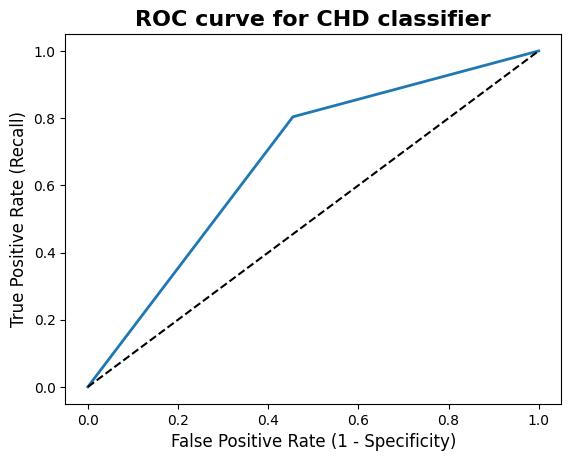

In [ ]:
y_pred = (y_proba >= 0.44).astype(int)

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, linewidth=2)
plt.plot([0,1], [0,1], "k--" )
plt.title("ROC curve for CHD classifier")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.show()

### 3.6. Confusion Matrix

- Accuracy - 59%
- Weighed avg f1-score - 64%
- Precision - 24%
- Recall - 80%

Recall metric is the most important one for this task because high number of false negatives could potentially be life-threatening, while high number of false positives wouldn't have negative consequences in practice.

We're able to maintain 80% recall without having an obnoxious number of false positives.

              precision    recall  f1-score   support

           0       0.94      0.55      0.69       576
           1       0.24      0.80      0.37       102

    accuracy                           0.58       678
   macro avg       0.59      0.67      0.53       678
weighted avg       0.83      0.58      0.64       678



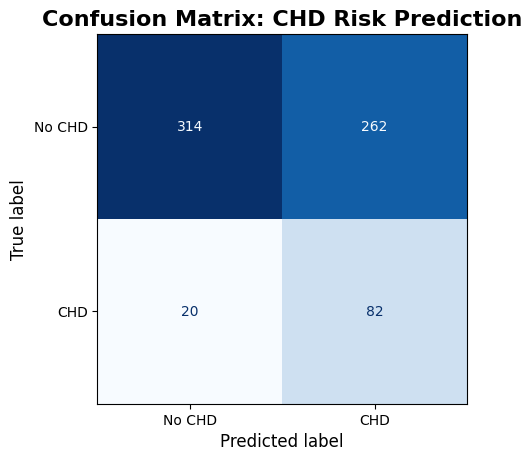

In [ ]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No CHD", "CHD"]
)
display.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix: CHD Risk Prediction")
plt.show()

### 3.7. Further Examination of the Model
Why did the inacurracies emerge. I'm interested in:
- Model's formula.
- Figuring out the bias of this model. Because the model performed well in the testing data, we know that variance is low, therefore, bias must be high.

In [ ]:
features = x_train.columns
coefs = model_pipeline.named_steps["logreg"].coef_[0]
df_coef = pd.DataFrame({
    "feature": features,
    "coeficient": coefs,
    "odds_ratio": np.exp(coefs)
}).sort_values(by="coeficient", ascending=False)

df_coef.round(3)

,feature,coeficient,odds_ratio
4,age,0.574,1.775
3,sys_bp,0.288,1.334
6,sex_binary,0.287,1.333
7,smoking_binary,0.244,1.276
5,comorbidities,0.160,1.174
2,tot_chol,0.140,1.151
0,log_glucose,0.102,1.108
1,bmi,0.026,1.026


- Age variable is massively overrepresented in this model. Its correlation with the target variable was 0.22 while it's coeficient in the formula is 0.574.
- Sex variable is also overrepresented. Its correlation with the target variable was 0.08 while it's coeficient in the formula is 0.574.

In [ ]:
"""
False negatives dataframe
"""

df_test = x_test
df_test["ten_year_chd"] = y_test
df_test["pred"] = y_pred

df_test.loc[
    (df_test.pred == 0) &
     (df_test.ten_year_chd == 1)
]

,log_glucose,bmi,tot_chol,sys_bp,age,comorbidities,sex_binary,smoking_binary,ten_year_chd,pred
2493,4.290459,26.5900,153.00,114.000,47.0,0.0,1.0,1.0,1,0
1641,4.094345,25.1800,232.00,115.000,46.0,0.0,0.0,1.0,1,0
3349,4.369448,27.4000,242.00,129.000,46.0,0.0,0.0,0.0,1,0
410,4.234107,27.0500,211.00,127.500,45.0,0.0,0.0,0.0,1,0
2684,4.189655,28.6800,244.00,118.500,38.0,0.0,1.0,0.0,1,0
1276,4.644391,24.0400,242.00,118.500,36.0,0.0,1.0,1.0,1,0
2204,4.290459,27.0200,279.00,135.000,52.0,0.0,0.0,0.0,1,0
3286,4.158883,22.8600,323.00,123.500,49.0,0.0,0.0,1.0,1,0
1062,4.234107,24.4000,210.00,103.000,40.0,0.0,0.0,1.0,1,0
1241,4.382027,20.8600,198.00,143.000,47.0,0.0,0.0,1.0,1,0


After examining false negatives dataframe we can clearly see model's bias regarding age:
- Median age value for all patients: **49**.
- Median age value for patients with confirmed chd risk: **55**.
- **Only 3 patients** were at or above the median age value for all patients.

Similarly, model is strongly biased towards diagnosing men.
- 17/20 of false negatives were women.

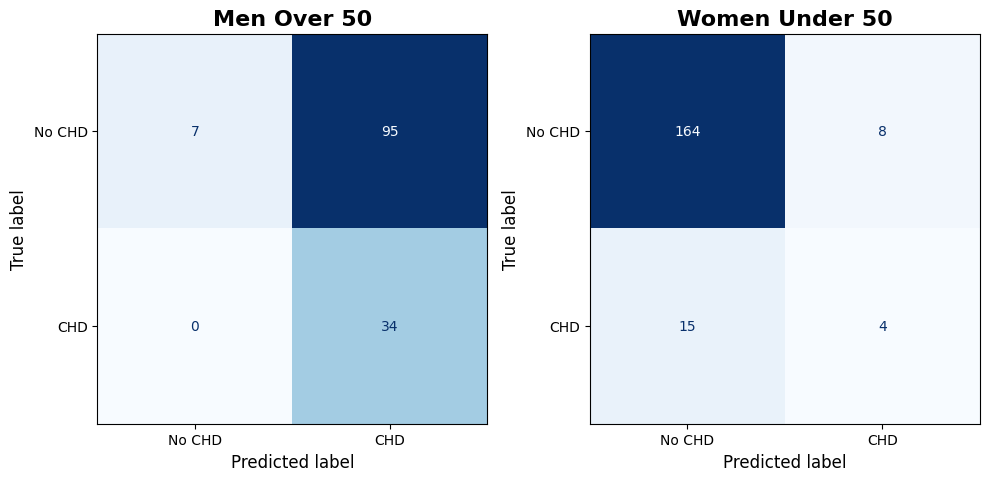

In [ ]:
men_over_50 = (
    (df_test["sex_binary"] == 1) &
     (df_test["age"] > 50)
)
y_true_men = y_test[men_over_50]
y_pred_men = y_pred[men_over_50]

women_under_50 = (
    (df_test["sex_binary"] == 0) &
     (df_test["age"] < 50)
)
y_true_women = y_test[women_under_50]
y_pred_women = y_pred[women_under_50]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

cm_men = confusion_matrix(y_true_men, y_pred_men)
display_men = ConfusionMatrixDisplay(
    confusion_matrix=cm_men,
    display_labels=["No CHD", "CHD"]
)
display_men.plot(ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Men Over 50")

cm_women = confusion_matrix(y_true_women, y_pred_women)
display_women = ConfusionMatrixDisplay(
    confusion_matrix=cm_women,
    display_labels=["No CHD", "CHD"]
)
display_women.plot(ax=ax[1], cmap="Blues", colorbar=False)
ax[1].set_title("Women Under 50")

plt.tight_layout()
plt.show()

# 4. Improvements
- Good idea to compare different machine learning models with one another and choosing the most accurate one.
- More entries in the dataset could improve model's performance
- Could be possible to engineer some more features, for example, combined blood pressure feature, packs_per_day instead of cigs_per_day.
- Geographic variable describing patient's region of origin is necessary, if this model is to be applied outside USA. It could also help to lower age-sex bias.
- Another way to manage bias - shrinking the weight of the age-sex coeficients by applying regularization.
